Import the libraries we need

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("dataset.csv")

data.head()

,Age,Height,Weight,Gender,Likeness
0,53,153.278361,79.183453,Male,Samosa
1,56,199.333636,60.453554,Male,Samosa
2,40,176.137288,79.703309,Female,Samosa
3,64,168.847337,57.181763,Female,Biryani
4,47,176.453651,95.345925,Male,Samosa


We are going to be comparing age and height using a scatter plot

Ages range from 18 years old to 65 years old

Heights range from ~150 cm to ~200 cm

In [34]:
ages = data["Age"]
heights = data["Height"]

In [37]:
ages.head()

0    53
1    56
2    40
3    64
4    47
Name: Age, dtype: int64

In [36]:
heights.head()

0    153.278361
1    199.333636
2    176.137288
3    168.847337
4    176.453651
Name: Height, dtype: float64

We are going to use pandas built-in functions to help us first

In [63]:
age_mean = ages.mean()
height_mean = heights.mean()

age_std = ages.std()
height_std = heights.std()

r = ages.corr(heights)

In [62]:
a = r * (height_std / age_std)
b = height_mean - a * age_mean

y_hat = a * ages + b

y_hat.head()

0    174.721047
1    174.905780
2    173.920538
3    175.398400
4    174.351581
Name: Age, dtype: float64

Now we are going to use math and do it ourselves

In [53]:
import math

n = len(ages)

age_mean_2 = 0
for i in range(n):
    age_mean_2 += ages[i]
age_mean_2 /= n

height_mean_2 = 0
for i in range(n):
    height_mean_2 += heights[i]
height_mean_2 /= n


In [58]:
age_std_2 = 0
for i in range(n):
    age_std_2 += (ages[i] - age_mean_2) ** 2
age_std_2 /= n - 1
age_std_2 = math.sqrt(age_std_2)

height_std_2 = 0
for i in range(n):
    height_std_2 += (heights[i] - height_mean_2) ** 2
height_std_2 /= n - 1
height_std_2 = math.sqrt(height_std_2)

In [61]:
r_2 = 0
for i in range(n):
    r_2 += ((ages[i] - age_mean_2) / age_std_2) * ((heights[i] - height_mean_2) / height_std_2)
r_2 /= n - 1

In [65]:
a_2 = r_2 * (height_std_2 / age_std_2)
b_2 = height_mean_2 - (a_2 * age_mean_2)

y_hat_2 = a_2 * ages + b_2

y_hat_2.head()

0    174.721047
1    174.905780
2    173.920538
3    175.398400
4    174.351581
Name: Age, dtype: float64

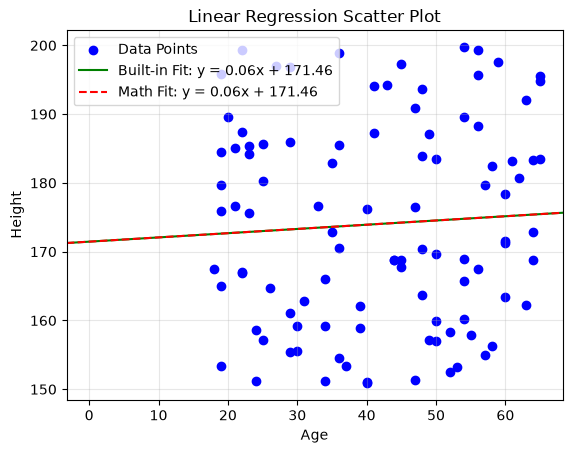

In [75]:
plt.scatter(ages, heights, color="blue", label="Data Points")

plt.axline(xy1=(0, b), slope=a, color='green', linestyle='solid', label=f'Built-in Fit: y = {a:.2f}x + {b:.2f}')
plt.axline(xy1=(0, b_2), slope=a_2, color='red', linestyle='--', label=f'Math Fit: y = {a_2:.2f}x + {b_2:.2f}')

plt.title("Linear Regression Scatter Plot")
plt.xlabel("Age")
plt.ylabel("Height")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()